<a href="https://colab.research.google.com/github/ge25anshika-hue/US-Housing/blob/main/housing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IndentationError: unexpected indent (2799694063.py, line 530)

DOWNLOADING DATA FROM FRED

Raw data shape: (1441, 6)

Raw data:
            House_Price_Index  Mortgage_Rate  Unemployment_Rate    CPI  \
DATE                                                                     
2003-01-01             279.44            NaN                5.8  182.6   
2003-01-03                NaN           5.85                NaN    NaN   
2003-01-10                NaN           5.95                NaN    NaN   
2003-01-17                NaN           5.97                NaN    NaN   
2003-01-24                NaN           5.91                NaN    NaN   

             Real_GDP  Housing_Starts  
DATE                                   
2003-01-01  14614.141          1853.0  
2003-01-03        NaN             NaN  
2003-01-10        NaN             NaN  
2003-01-17        NaN             NaN  
2003-01-24        NaN             NaN  

FINAL DATASET

Number of observations: 87
Start date: 2004-06-30 00:00:00
End date: 2025-12-31 00:00:00

Missing values:
House_Price_In

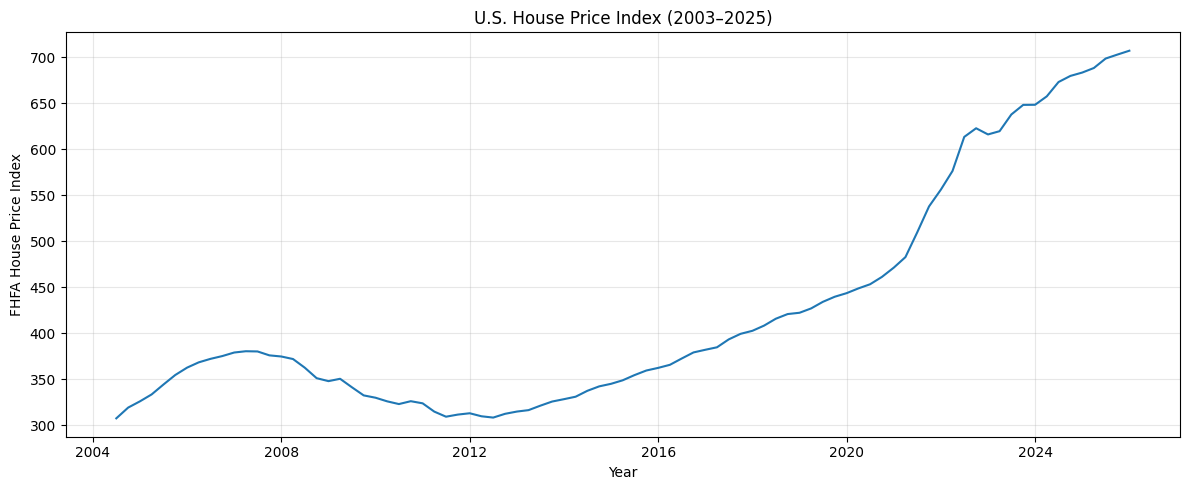

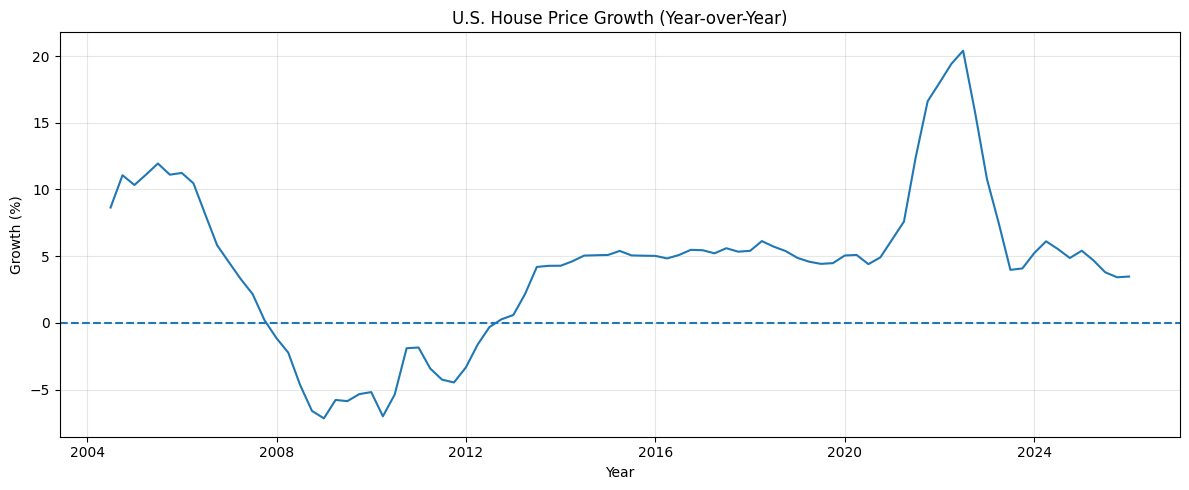

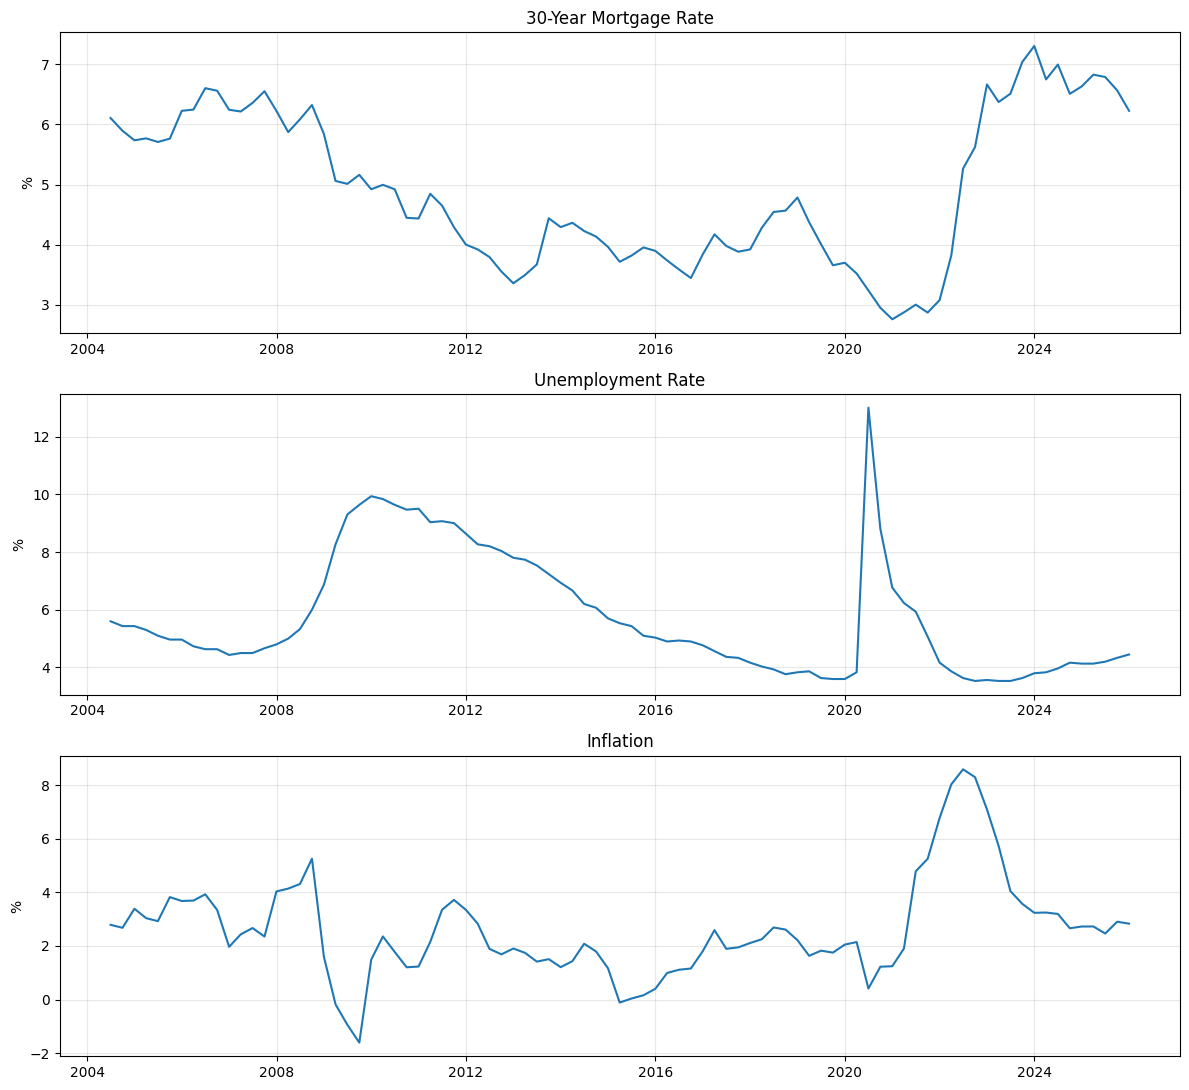


CORRELATION MATRIX
                       House_Price_Growth  Mortgage_Rate  Unemployment_Rate  \
House_Price_Growth                   1.00          -0.06              -0.59   
Mortgage_Rate                       -0.06           1.00              -0.34   
Unemployment_Rate                   -0.59          -0.34               1.00   
Inflation                            0.53           0.31              -0.43   
GDP_Growth                           0.50           0.00              -0.48   
Housing_Starts_Growth                0.32          -0.54               0.03   

                       Inflation  GDP_Growth  Housing_Starts_Growth  
House_Price_Growth          0.53        0.50                   0.32  
Mortgage_Rate               0.31        0.00                  -0.54  
Unemployment_Rate          -0.43       -0.48                   0.03  
Inflation                   1.00        0.41                   0.00  
GDP_Growth                  0.41        1.00                   0.53  
Housin

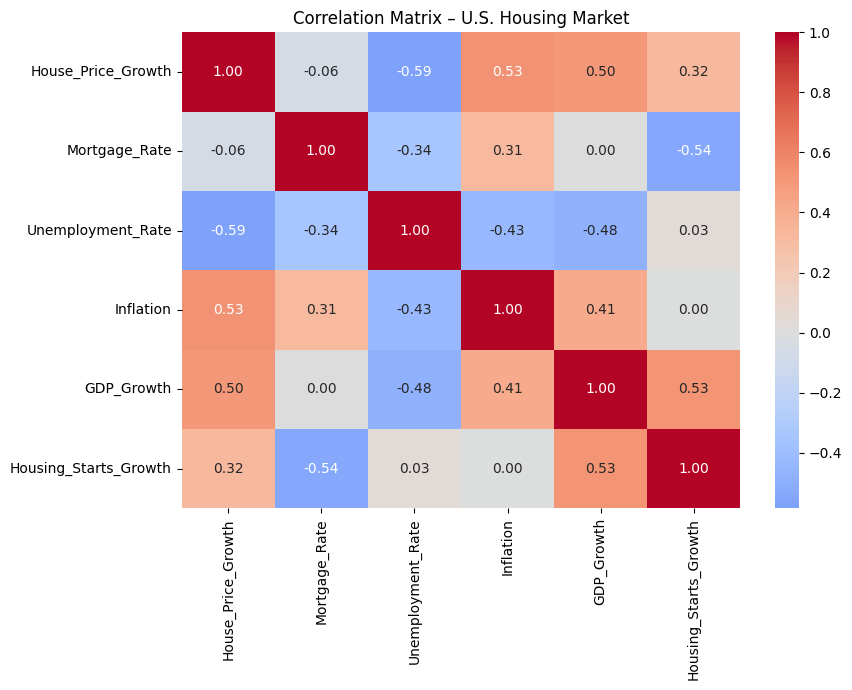


TRAIN-TEST SPLIT

Training observations: 69
Testing observations: 18

Training period:
2004-06-30 00:00:00 to 2021-06-30 00:00:00

Testing period:
2021-09-30 00:00:00 to 2025-12-31 00:00:00

MULTICOLLINEARITY CHECK – VIF
                  Variable   VIF
0                    const  1.00
1  House_Price_Growth_Lag1  2.18
2       Mortgage_Rate_Lag1  3.31
3   Unemployment_Rate_Lag1  2.08
4                Inflation  1.83
5               GDP_Growth  2.31
6    Housing_Starts_Growth  4.55

REVISED OLS REGRESSION
                            OLS Regression Results                            
Dep. Variable:     House_Price_Growth   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     336.6
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           2.45e-45
Time:                        06:54:20   Log-Likelihood:                -94.465
No. Observations

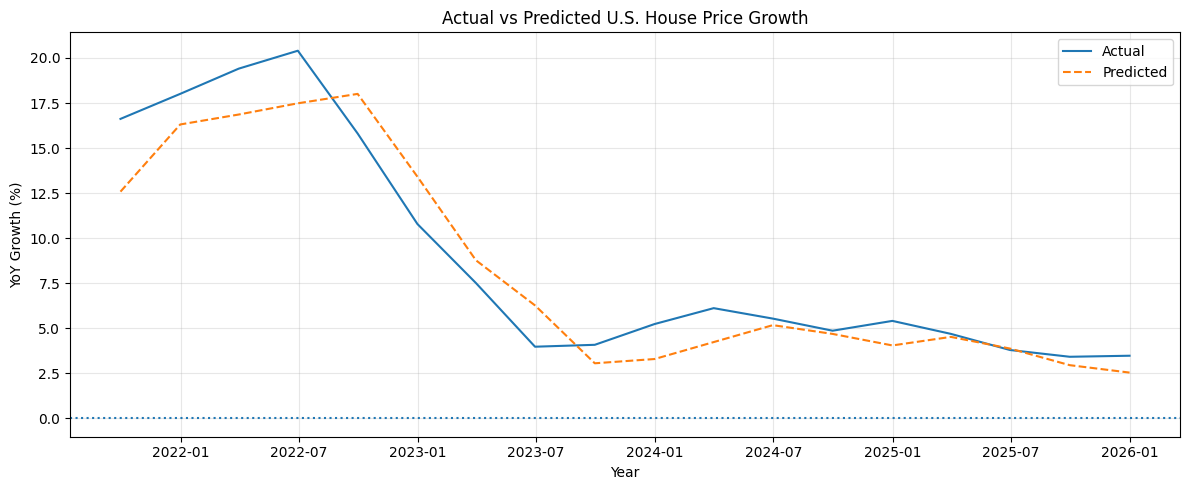


COEFFICIENT TABLE
               Variable  Coefficient  P_Value Significance
                  const       0.5584   0.6633             
House_Price_Growth_Lag1       0.9769   0.0000          ***
     Mortgage_Rate_Lag1      -0.2360   0.5051             
 Unemployment_Rate_Lag1       0.1278   0.0775            *
              Inflation      -0.2526   0.1753             
             GDP_Growth       0.2051   0.0582            *
  Housing_Starts_Growth       0.0118   0.5195             


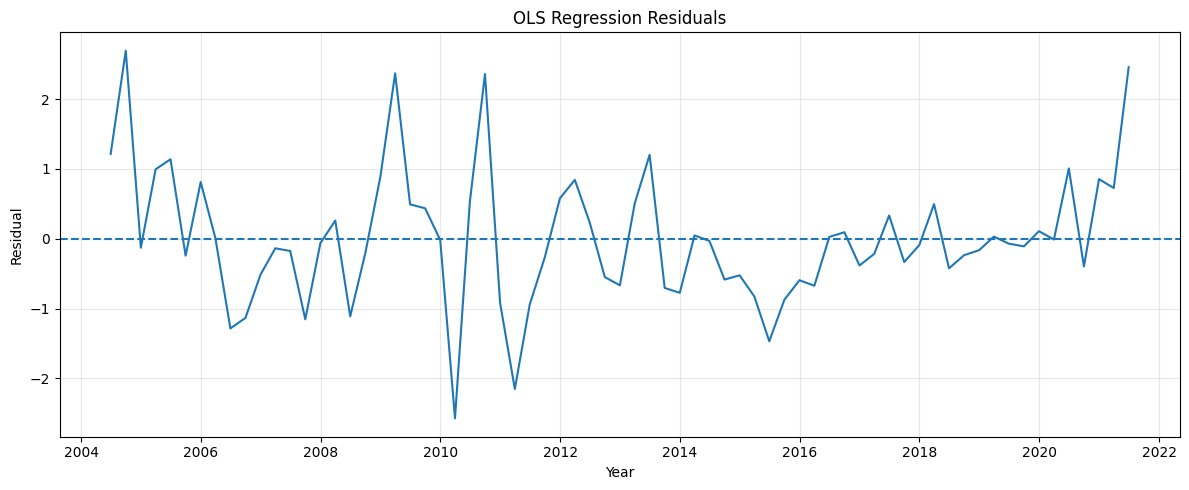


FINAL PROJECT SUMMARY

Dataset period: 2004-06-30 to 2025-12-31
Total observations: 87
Training observations: 69
Testing observations: 18

Revised OLS MAE: 1.55
Revised OLS RMSE: 1.89
Revised OLS R²: 0.90

Benchmark MAE: 5.76
Benchmark RMSE: 8.33
Benchmark R²: -0.92

HOW TO READ YOUR RESULTS

1. Coefficient:
   Shows the estimated direction and size of the association,
   holding the other variables constant.

2. P-value:
   Below 0.05 = statistically significant at the 5% level.
   Between 0.05 and 0.10 = weaker evidence at the 10% level.

3. MAE:
   Average absolute prediction error in percentage points.
   Lower is better.

4. RMSE:
   Prediction error measure that gives greater weight to
   larger errors.
   Lower is better.

5. Out-of-sample:
   Performance on later observations that were not used
   to estimate the regression coefficients.

6. R-squared:
   Measures how well the predictions explain variation
   in the test observations relative to the test-sample mean.

IMPORTAN

In [12]:
# ============================================================
# U.S. HOUSING MARKET DRIVERS & MACROECONOMIC ANALYSIS
# 2003–2025 | Quarterly Data
# ============================================================

# OBJECTIVE:
# Examine how selected macroeconomic and housing-market
# variables are associated with U.S. house-price growth.
#
# KEY FEATURES:
# - No DATE used as a model predictor
# - Federal Funds Rate removed because of high collinearity
# - One-quarter lags added where economically sensible
# - Chronological train/test split
# - Historical-mean benchmark
# - OLS with HAC-robust standard errors
# - VIF multicollinearity check
#
# IMPORTANT:
# Regression coefficients represent associations, not causal effects.
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas_datareader import data as web

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 2. DATE RANGE


START_DATE = "2003-01-01"
END_DATE = "2025-12-31"

# 3. FRED SERIES


# USSTHPI       = FHFA All-Transactions House Price Index
# MORTGAGE30US = 30-Year Fixed Mortgage Rate
# UNRATE       = U.S. Unemployment Rate
# CPIAUCSL      = Consumer Price Index
# GDPC1        = Real GDP
# HOUST        = Housing Starts

series = {
    "House_Price_Index": "USSTHPI",
    "Mortgage_Rate": "MORTGAGE30US",
    "Unemployment_Rate": "UNRATE",
    "CPI": "CPIAUCSL",
    "Real_GDP": "GDPC1",
    "Housing_Starts": "HOUST"
}


# 4. DOWNLOAD DATA

print("=" * 70)
print("DOWNLOADING DATA FROM FRED")
print("=" * 70)

raw_data = web.DataReader(
    list(series.values()),
    "fred",
    START_DATE,
    END_DATE
)

# Rename variables
reverse_series = {
    value: key for key, value in series.items()
}

raw_data.rename(
    columns=reverse_series,
    inplace=True
)

print("\nRaw data shape:", raw_data.shape)
print("\nRaw data:")
print(raw_data.head())


# 5. CONVERT TO QUARTERLY FREQUENCY


# - House Price Index: quarterly
# - Mortgage Rate: weekly -> quarterly average
# - Unemployment: monthly -> quarterly average
# - CPI: monthly -> quarterly average
# - GDP: quarterly
# - Housing Starts: monthly -> quarterly average

quarterly = pd.DataFrame()

quarterly["House_Price_Index"] = (
    raw_data["House_Price_Index"]
    .resample("Q")
    .mean()
)

quarterly["Mortgage_Rate"] = (
    raw_data["Mortgage_Rate"]
    .resample("Q")
    .mean()
)

quarterly["Unemployment_Rate"] = (
    raw_data["Unemployment_Rate"]
    .resample("Q")
    .mean()
)

quarterly["CPI"] = (
    raw_data["CPI"]
    .resample("Q")
    .mean()
)

quarterly["Real_GDP"] = (
    raw_data["Real_GDP"]
    .resample("Q")
    .mean()
)

quarterly["Housing_Starts"] = (
    raw_data["Housing_Starts"]
    .resample("Q")
    .mean()
)

# 6. CREATE ECONOMIC VARIABLES

# Year-over-year house-price growth
quarterly["House_Price_Growth"] = (
    quarterly["House_Price_Index"]
    .pct_change(4) * 100
)

# Year-over-year inflation
quarterly["Inflation"] = (
    quarterly["CPI"]
    .pct_change(4) * 100
)

# Year-over-year GDP growth
quarterly["GDP_Growth"] = (
    quarterly["Real_GDP"]
    .pct_change(4) * 100
)

# Year-over-year housing-start growth
quarterly["Housing_Starts_Growth"] = (
    quarterly["Housing_Starts"]
    .pct_change(4) * 100
)
# 7. CREATE ONE-QUARTER LAGS

# Lag 1 = previous quarter

quarterly["House_Price_Growth_Lag1"] = (
    quarterly["House_Price_Growth"]
    .shift(1)
)

quarterly["Mortgage_Rate_Lag1"] = (
    quarterly["Mortgage_Rate"]
    .shift(1)
)

quarterly["Unemployment_Rate_Lag1"] = (
    quarterly["Unemployment_Rate"]
    .shift(1)
)

# 8. SELECT FINAL VARIABLES

analysis_data = quarterly[
    [
        "House_Price_Index",
        "House_Price_Growth",
        "House_Price_Growth_Lag1",
        "Mortgage_Rate",
        "Mortgage_Rate_Lag1",
        "Unemployment_Rate",
        "Unemployment_Rate_Lag1",
        "Inflation",
        "GDP_Growth",
        "Housing_Starts_Growth"
    ]
].copy()

# 9. REMOVE MISSING OBSERVATIONS

analysis_data.dropna(
    inplace=True
)
# 10. BASIC DATA CHECK


print("\n" + "=" * 70)
print("FINAL DATASET")
print("=" * 70)

print(
    "\nNumber of observations:",
    len(analysis_data)
)

print(
    "Start date:",
    analysis_data.index.min()
)

print(
    "End date:",
    analysis_data.index.max()
)

print("\nMissing values:")
print(analysis_data.isnull().sum())

print("\nLast 5 observations:")
print(analysis_data.tail())

# 11. DESCRIPTIVE STATISTICS


print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

descriptive_variables = [
    "House_Price_Growth",
    "Mortgage_Rate",
    "Unemployment_Rate",
    "Inflation",
    "GDP_Growth",
    "Housing_Starts_Growth"
]

print(
    analysis_data[
        descriptive_variables
    ]
    .describe()
    .round(2)
)

# 12. HOUSE PRICE INDEX TREND


plt.figure(figsize=(12, 5))

plt.plot(
    analysis_data.index,
    analysis_data["House_Price_Index"]
)

plt.title("U.S. House Price Index (2003–2025)")
plt.xlabel("Year")
plt.ylabel("FHFA House Price Index")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 13. HOUSE PRICE GROWTH

plt.figure(figsize=(12, 5))

plt.plot(
    analysis_data.index,
    analysis_data["House_Price_Growth"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "U.S. House Price Growth (Year-over-Year)"
)

plt.xlabel("Year")
plt.ylabel("Growth (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 14. MACROECONOMIC TRENDS

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 11)
)

axes[0].plot(
    analysis_data.index,
    analysis_data["Mortgage_Rate"]
)

axes[0].set_title(
    "30-Year Mortgage Rate"
)

axes[0].set_ylabel("%")
axes[0].grid(alpha=0.3)


axes[1].plot(
    analysis_data.index,
    analysis_data["Unemployment_Rate"]
)

axes[1].set_title(
    "Unemployment Rate"
)

axes[1].set_ylabel("%")
axes[1].grid(alpha=0.3)


axes[2].plot(
    analysis_data.index,
    analysis_data["Inflation"]
)

axes[2].set_title(
    "Inflation"
)

axes[2].set_ylabel("%")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 15. CORRELATION MATRIX


correlation_variables = [
    "House_Price_Growth",
    "Mortgage_Rate",
    "Unemployment_Rate",
    "Inflation",
    "GDP_Growth",
    "Housing_Starts_Growth"
]

correlation_matrix = (
    analysis_data[
        correlation_variables
    ]
    .corr()
)

print("\n" + "=" * 70)
print("CORRELATION MATRIX")
print("=" * 70)

print(
    correlation_matrix.round(2)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix – U.S. Housing Market"
)

plt.tight_layout()
plt.show()

# 16. CHRONOLOGICAL TRAIN-TEST SPLIT


# Earlier observations = training
# Later observations = testing
# No random splitting

train_size = int(
    len(analysis_data) * 0.80
)

train = analysis_data.iloc[
    :train_size
].copy()

test = analysis_data.iloc[
    train_size:
].copy()

print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print(
    "\nTraining observations:",
    len(train)
)

print(
    "Testing observations:",
    len(test)
)

print("\nTraining period:")
print(
    train.index.min(),
    "to",
    train.index.max()
)

print("\nTesting period:")
print(
    test.index.min(),
    "to",
    test.index.max()
)

# 17. DEFINE MODEL VARIABLES

# Deliberately excluded:
# - DATE
# - Federal Funds Rate
#
# Federal Funds Rate was removed because it was highly
# correlated with Mortgage Rate in the earlier model.

X_variables = [
    "House_Price_Growth_Lag1",
    "Mortgage_Rate_Lag1",
    "Unemployment_Rate_Lag1",
    "Inflation",
    "GDP_Growth",
    "Housing_Starts_Growth"
]

Y_variable = "House_Price_Growth"


X_train = train[
    X_variables
]

y_train = train[
    Y_variable
]

X_test = test[
    X_variables
]

y_test = test[
    Y_variable
]

# 18. MULTICOLLINEARITY CHECK – VIF

X_vif = sm.add_constant(
    X_train,
    has_constant="add"
)

vif_table = pd.DataFrame()

vif_table["Variable"] = X_vif.columns

vif_table["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(
        X_vif.shape[1]
    )
]

print("\n" + "=" * 70)
print("MULTICOLLINEARITY CHECK – VIF")
print("=" * 70)

print(
    vif_table.round(2)
)

# 19. OLS REGRESSION

X_train_ols = sm.add_constant(
    X_train,
    has_constant="add"
)

X_test_ols = sm.add_constant(
    X_test,
    has_constant="add"
)

model = sm.OLS(
    y_train,
    X_train_ols
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 4
    }
)

# 20. REGRESSION RESULTS

print("\n" + "=" * 70)
print("REVISED OLS REGRESSION")
print("=" * 70)

print(
    model.summary()
)

# 21. ACTUAL VS PREDICTED VALUES

test_predictions = model.predict(
    X_test_ols
)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": test_predictions
})

print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED")
print("=" * 70)

print(
    comparison.round(2)
)

# 22. MODEL PERFORMANCE


mae = mean_absolute_error(
    y_test,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

r2 = r2_score(
    y_test,
    test_predictions
)

# 23. SIMPLE HISTORICAL-MEAN BENCHMARK

# Predict every test observation using the average
# house-price growth from the training period.

benchmark_prediction = np.repeat(
    y_train.mean(),
    len(y_test)
)

benchmark_mae = mean_absolute_error(
    y_test,
    benchmark_prediction
)

benchmark_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        benchmark_prediction
    )
)

benchmark_r2 = r2_score(
    y_test,
    benchmark_prediction
)



# 24. COMPARE MODEL WITH BENCHMARK


performance_table = pd.DataFrame({

    "Model": [
        "Revised OLS",
        "Historical Mean Benchmark"
    ],

    "MAE": [
        mae,
        benchmark_mae
    ],

    "RMSE": [
        rmse,
        benchmark_rmse
    ],

    "R2": [
        r2,
        benchmark_r2
    ]
})

print("\n" + "=" * 70)
print("OUT-OF-SAMPLE PERFORMANCE")
print("=" * 70)

print(
    performance_table.round(2)
)


# 25. ACTUAL VS PREDICTED GRAPH


plt.figure(figsize=(12, 5))

plt.plot(
    comparison.index,
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison.index,
    comparison["Predicted"],
    linestyle="--",
    label="Predicted"
)

plt.axhline(
    y=0,
    linestyle=":"
)

plt.title(
    "Actual vs Predicted U.S. House Price Growth"
)

plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 26. REGRESSION COEFFICIENT TABLE


coefficient_table = pd.DataFrame({

    "Variable": model.params.index,

    "Coefficient": model.params.values,

    "P_Value": model.pvalues.values
})

coefficient_table["Significance"] = np.where(
    coefficient_table["P_Value"] < 0.01,
    "***",
    np.where(
        coefficient_table["P_Value"] < 0.05,
        "**",
        np.where(
            coefficient_table["P_Value"] < 0.10,
            "*",
            ""
        )
    )
)

print("\n" + "=" * 70)
print("COEFFICIENT TABLE")
print("=" * 70)

print(
    coefficient_table
    .round(4)
    .to_string(index=False)
)

# 27. RESIDUAL ANALYSIS

residuals = model.resid

plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "OLS Regression Residuals"
)

plt.xlabel("Year")
plt.ylabel("Residual")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 28. SAVE OUTPUT FILES

analysis_data.to_csv(
    "US_Housing_Market_Analysis_2003_2025.csv"
)

comparison.to_csv(
    "Housing_Model_Actual_vs_Predicted.csv"
)

coefficient_table.to_csv(
    "Housing_Model_Coefficients.csv",
    index=False
)

performance_table.to_csv(
    "Housing_Model_Performance.csv",
    index=False
)

vif_table.to_csv(
    "Housing_VIF_Check.csv",
    index=False
)

# 29. FINAL SUMMARY

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(
    f"\nDataset period: "
    f"{analysis_data.index.min().strftime('%Y-%m-%d')} "
    f"to "
    f"{analysis_data.index.max().strftime('%Y-%m-%d')}"
)

print(
    f"Total observations: {len(analysis_data)}"
)

print(
    f"Training observations: {len(train)}"
)

print(
    f"Testing observations: {len(test)}"
)

print(
    f"\nRevised OLS MAE: {mae:.2f}"
)

print(
    f"Revised OLS RMSE: {rmse:.2f}"
)

print(
    f"Revised OLS R²: {r2:.2f}"
)

print(
    f"\nBenchmark MAE: {benchmark_mae:.2f}"
)

print(
    f"Benchmark RMSE: {benchmark_rmse:.2f}"
)

print(
    f"Benchmark R²: {benchmark_r2:.2f}"
)

# 30. MODEL INTERPRETATION GUIDE


print("\n" + "=" * 70)
print("HOW TO READ YOUR RESULTS")
print("=" * 70)

print("""
1. Coefficient:
   Shows the estimated direction and size of the association,
   holding the other variables constant.

2. P-value:
   Below 0.05 = statistically significant at the 5% level.
   Between 0.05 and 0.10 = weaker evidence at the 10% level.

3. MAE:
   Average absolute prediction error in percentage points.
   Lower is better.

4. RMSE:
   Prediction error measure that gives greater weight to
   larger errors.
   Lower is better.

5. Out-of-sample:
   Performance on later observations that were not used
   to estimate the regression coefficients.

6. R-squared:
   Measures how well the predictions explain variation
   in the test observations relative to the test-sample mean.

IMPORTANT:
Regression coefficients show associations, not causal effects.
""")

In [13]:

# VIF - MULTICOLLINEARITY CHECK
vif_table = pd.DataFrame({
    "Variable": X_train.columns,
    "VIF": [
        variance_inflation_factor(
            X_train.values,
            i
        )
        for i in range(X_train.shape[1])
    ]
})

print("\n" + "=" * 70)
print("VIF - MULTICOLLINEARITY CHECK")
print("=" * 70)

print(
    vif_table.round(2).to_string(index=False)
)


VIF - MULTICOLLINEARITY CHECK
               Variable  VIF
House_Price_Growth_Lag1 2.18
     Mortgage_Rate_Lag1 3.31
 Unemployment_Rate_Lag1 2.08
              Inflation 1.83
             GDP_Growth 2.31
  Housing_Starts_Growth 4.55


In [14]:

# NAIVE LAST-QUARTER BENCHMARK

# Predict current house-price growth using ONLY
# the previous quarter's house-price growth.

naive_prediction = test["House_Price_Growth_Lag1"]

naive_mae = mean_absolute_error(
    y_test,
    naive_prediction
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_prediction
    )
)

naive_r2 = r2_score(
    y_test,
    naive_prediction
)

print("\n" + "=" * 70)
print("NAIVE LAST-QUARTER BENCHMARK")
print("=" * 70)

print(f"Naive MAE:  {naive_mae:.2f}")
print(f"Naive RMSE: {naive_rmse:.2f}")
print(f"Naive R²:   {naive_r2:.2f}")


# Compare all three
comparison_models = pd.DataFrame({
    "Model": [
        "Revised OLS",
        "Historical Mean",
        "Naive Last-Quarter"
    ],
    "MAE": [
        mae,
        benchmark_mae,
        naive_mae
    ],
    "RMSE": [
        rmse,
        benchmark_rmse,
        naive_rmse
    ],
    "R2": [
        r2,
        benchmark_r2,
        naive_r2
    ]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(comparison_models.round(2).to_string(index=False))


NAIVE LAST-QUARTER BENCHMARK
Naive MAE:  1.69
Naive RMSE: 2.32
Naive R²:   0.85

MODEL COMPARISON
             Model  MAE  RMSE    R2
       Revised OLS 1.55  1.89  0.90
   Historical Mean 5.76  8.33 -0.92
Naive Last-Quarter 1.69  2.32  0.85


In [16]:

# TRUE ONE-QUARTER-AHEAD FORECASTING VERSION

forecast_data = quarterly.copy()

# Lag all predictors by one quarter
forecast_data["HPG_L1"] = forecast_data["House_Price_Growth"].shift(1)
forecast_data["Mortgage_L1"] = forecast_data["Mortgage_Rate"].shift(1)
forecast_data["Unemployment_L1"] = forecast_data["Unemployment_Rate"].shift(1)
forecast_data["Inflation_L1"] = forecast_data["Inflation"].shift(1)
forecast_data["GDP_Growth_L1"] = forecast_data["GDP_Growth"].shift(1)
forecast_data["Housing_Starts_Growth_L1"] = (
    forecast_data["Housing_Starts_Growth"].shift(1)
)

forecast_data = forecast_data.dropna()

forecast_X = [
    "HPG_L1",
    "Mortgage_L1",
    "Unemployment_L1",
    "Inflation_L1",
    "GDP_Growth_L1",
    "Housing_Starts_Growth_L1"
]

forecast_y = "House_Price_Growth"

# Chronological split
split = int(len(forecast_data) * 0.80)

forecast_train = forecast_data.iloc[:split]
forecast_test = forecast_data.iloc[split:]

Xf_train = sm.add_constant(
    forecast_train[forecast_X],
    has_constant="add"
)

Xf_test = sm.add_constant(
    forecast_test[forecast_X],
    has_constant="add"
)

yf_train = forecast_train[forecast_y]
yf_test = forecast_test[forecast_y]

forecast_model = sm.OLS(
    yf_train,
    Xf_train
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 4}
)

forecast_pred = forecast_model.predict(Xf_test)

forecast_mae = mean_absolute_error(
    yf_test,
    forecast_pred
)

forecast_rmse = np.sqrt(
    mean_squared_error(
        yf_test,
        forecast_pred
    )
)

forecast_r2 = r2_score(
    yf_test,
    forecast_pred
)

print("\n" + "=" * 70)
print("ONE-QUARTER-AHEAD FORECASTING MODEL")
print("=" * 70)

print(f"MAE:  {forecast_mae:.2f}")
print(f"RMSE: {forecast_rmse:.2f}")
print(f"R²:   {forecast_r2:.2f}")

print("\nModel summary:")
print(forecast_model.summary())


ONE-QUARTER-AHEAD FORECASTING MODEL
MAE:  1.56
RMSE: 1.98
R²:   0.89

Model summary:
                            OLS Regression Results                            
Dep. Variable:     House_Price_Growth   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     339.8
Date:                Sat, 26 Sep 2026   Prob (F-statistic):           1.85e-45
Time:                        07:00:08   Log-Likelihood:                -99.731
No. Observations:                  69   AIC:                             213.5
Df Residuals:                      62   BIC:                             229.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------